In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [4]:
file_path= "/content/drive/MyDrive/AI-ML_Portfolio/Student-Performance-Predictor/data/StudentsPerformance.csv"
df = pd.read_csv(file_path)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [9]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [10]:
# Check category counts

for col in df.select_dtypes(include='object').columns:
  print(f"\n{col}")
  print(df[col].value_counts())


gender
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


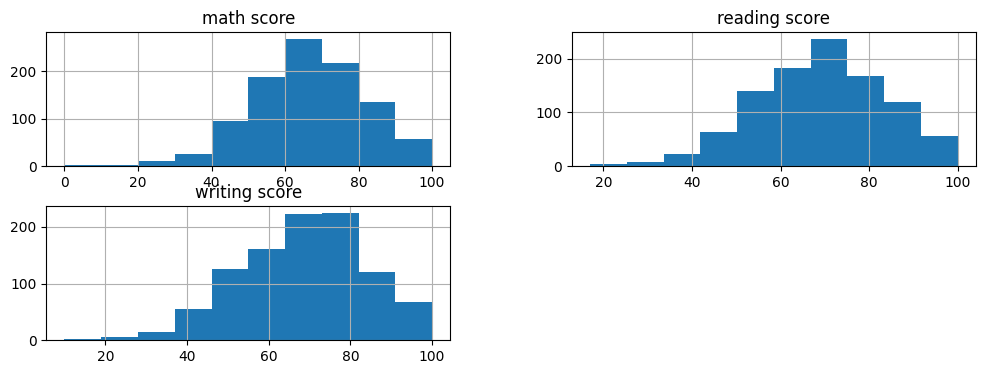

In [11]:
# Distribution of Scores

score_cols= ["math score", "reading score", "writing score"]

df[score_cols].hist(figsize=(12,4))
plt.show()

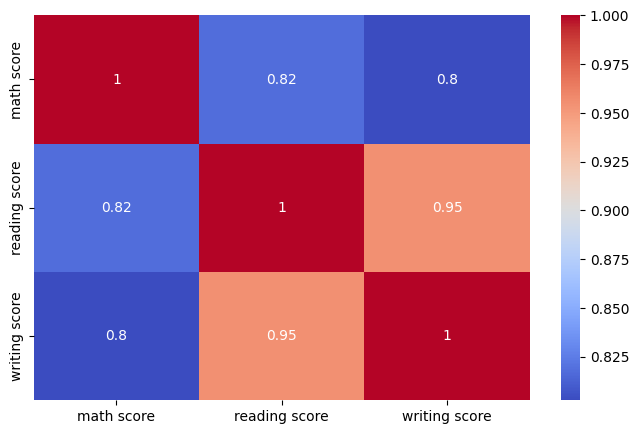

In [12]:
# Coorelation between scores

plt.figure(figsize=(8,5))

sns.heatmap(
    df[score_cols].corr(),
    annot= True,
    cmap="coolwarm"
)

plt.show()

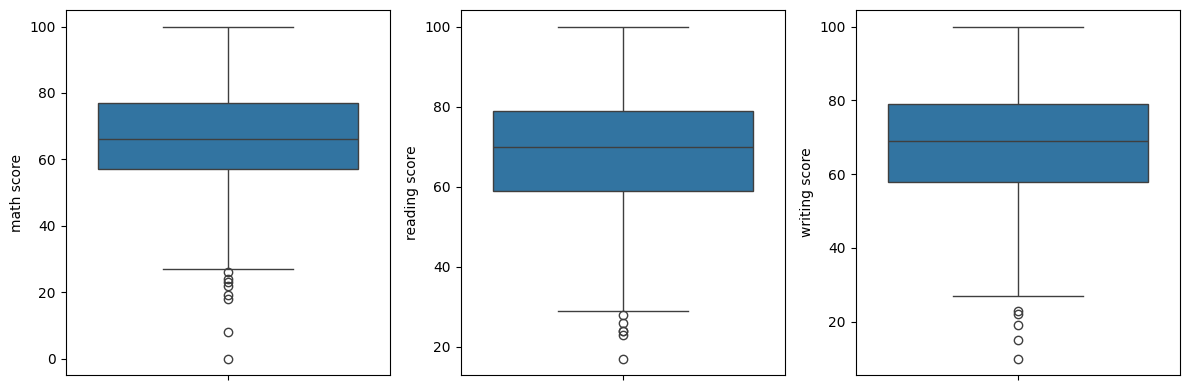

In [13]:
# Boxplots
plt.figure(figsize=(12,4))

for i,col in enumerate(score_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [14]:
# overall score
df["overall_score"]= (
    df["math score"]+
    df["writing score"]+
    df["reading score"]
)/3

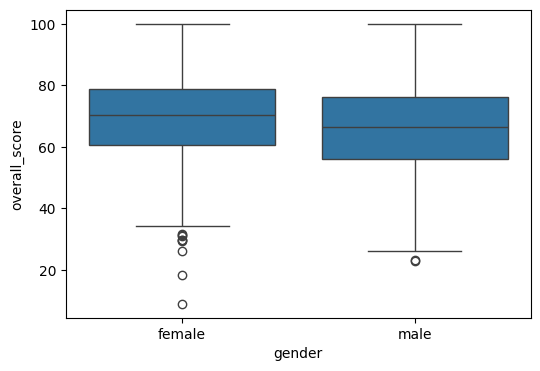

In [15]:
# gender vs performance

plt.figure(figsize=(6,4))

sns.boxplot(
    x= "gender",
    y= "overall_score",
    data= df
)

plt.show()

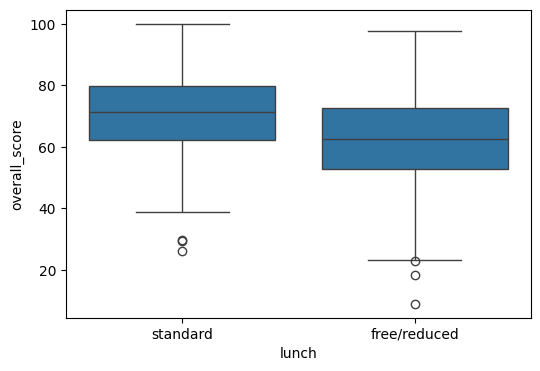

In [16]:
# lunch vs performance

plt.figure(figsize=(6,4))

sns.boxplot(
    x= "lunch",
    y= "overall_score",
    data= df
)

plt.show()

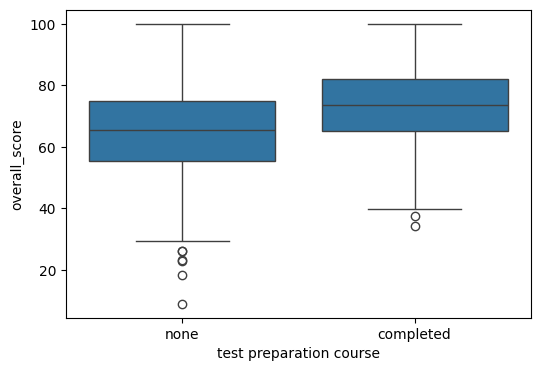

In [17]:
# test preparation course vs performance
plt.figure(figsize=(6,4))

sns.boxplot(
    x= "test preparation course",
    y= "overall_score",
    data= df
)

plt.show()

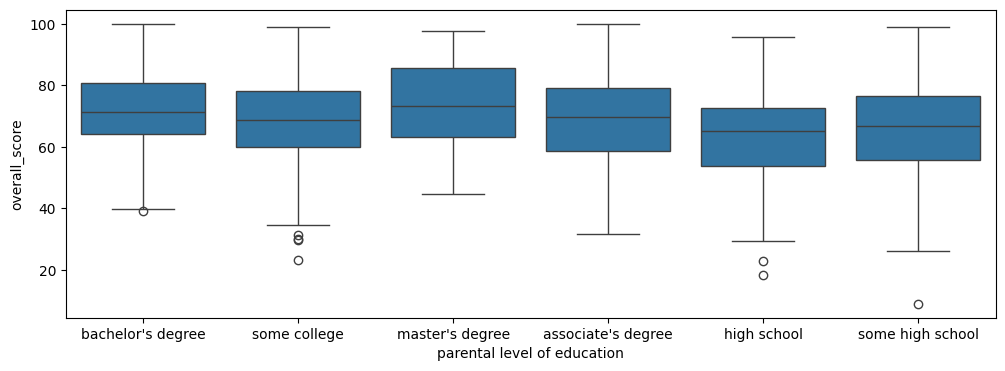

In [19]:
# parental level of education vs performance

plt.figure(figsize=(12,4))

sns.boxplot(
    x= "parental level of education",
    y= "overall_score",
    data= df
)

plt.show()

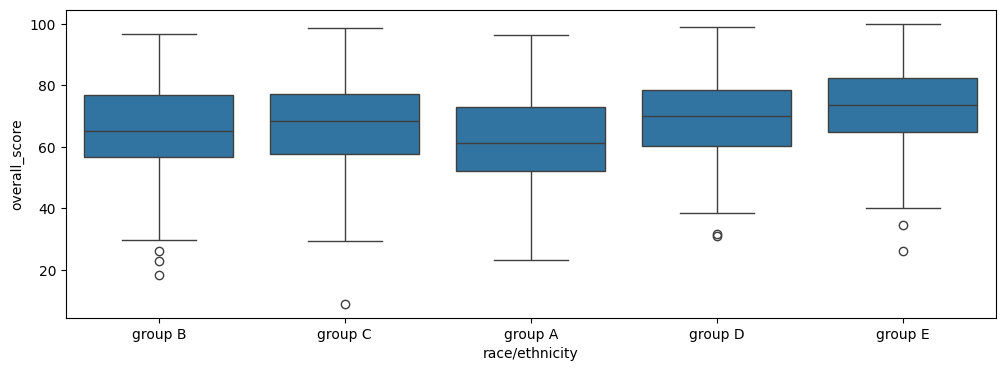

In [21]:
# race/ethnicity vs performance

plt.figure(figsize=(12,4))

sns.boxplot(
    x= "race/ethnicity",
    y= "overall_score",
    data= df
)

plt.show()

In [24]:
X= df.drop(
    columns=[
        "math score",
        "writing score",
        "reading score",
        "overall_score"
    ]
)

y= df["overall_score"]

print(f"{X.head()}\n")
print(y.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  
0                    none  
1               completed  
2                    none  
3                    none  
4                    none  

0    72.666667
1    82.333333
2    92.666667
3    49.333333
4    76.333333
Name: overall_score, dtype: float64


In [26]:
print(X.shape)
print(y.shape)

(1000, 5)
(1000,)


In [28]:
X_encoded= pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)
print(X_encoded.head())

(1000, 12)
   gender_male  race/ethnicity_group B  race/ethnicity_group C  \
0        False                    True                   False   
1        False                   False                    True   
2        False                    True                   False   
3         True                   False                   False   
4         True                   False                    True   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False   
1                   False                   False   
2                   False                   False   
3                   False                   False   
4                   False                   False   

   parental level of education_bachelor's degree  \
0                                           True   
1                                          False   
2                                          False   
3                                          False   
4            

In [29]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   gender_male                                    1000 non-null   bool 
 1   race/ethnicity_group B                         1000 non-null   bool 
 2   race/ethnicity_group C                         1000 non-null   bool 
 3   race/ethnicity_group D                         1000 non-null   bool 
 4   race/ethnicity_group E                         1000 non-null   bool 
 5   parental level of education_bachelor's degree  1000 non-null   bool 
 6   parental level of education_high school        1000 non-null   bool 
 7   parental level of education_master's degree    1000 non-null   bool 
 8   parental level of education_some college       1000 non-null   bool 
 9   parental level of education_some high school   1000 non-null   bool 
 10  l

In [33]:
# train- test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X_encoded,
    y,
    test_size= 0.2,
    random_state= 42
)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

(200,)

In [35]:
# Model Training

from sklearn.linear_model import LinearRegression

lr= LinearRegression()

lr.fit(X_train, y_train)

print("Model Trained Successfully!!!")

Model Trained Successfully!!!


In [36]:
# prediction
y_pred= lr.predict(X_test)

y_pred[:5]

array([70.52277256, 67.2809476 , 72.79594181, 56.36915946, 78.49679002])

In [37]:
# Model Evaluation(Through Cost fuctions)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae= mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
rmse= mse ** 0.5
r2= r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 10.490182374209294
MSE : 179.60234233623538
RMSE: 13.401579844788277
R²  : 0.16217185763155217


In [38]:
# random forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, rf_pred))

R²: -0.01861419507194917


In [39]:
importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                          Feature  Importance
10                                 lunch_standard    0.180608
11                   test preparation course_none    0.152550
0                                     gender_male    0.108189
6         parental level of education_high school    0.072663
1                          race/ethnicity_group B    0.071321
2                          race/ethnicity_group C    0.067826
5   parental level of education_bachelor's degree    0.065029
4                          race/ethnicity_group E    0.063058
9    parental level of education_some high school    0.061262
3                          race/ethnicity_group D    0.060181
8        parental level of education_some college    0.056104
7     parental level of education_master's degree    0.041210


In [40]:
import joblib

joblib.dump(lr, "student_performance_model.pkl")

print("Model saved successfully!!")

Model saved successfully!!
